✅ Paths set up!
📌 Loaded dataset : (2000, 2)
📌 Positive       : 1000
📌 Negative       : 1000

📌 Train size     : (1600, 10000)
📌 Test size      : (400, 10000)
📌 TF-IDF features: 10000

⏳ Training Logistic Regression...
  ✅ Logistic Regression
  Accuracy : 0.8325
              precision    recall  f1-score   support

    Negative       0.85      0.81      0.83       200
    Positive       0.82      0.85      0.84       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400


⏳ Training Naive Bayes...
  ✅ Naive Bayes
  Accuracy : 0.8075
              precision    recall  f1-score   support

    Negative       0.79      0.83      0.81       200
    Positive       0.82      0.79      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400


⏳ Training Linear S

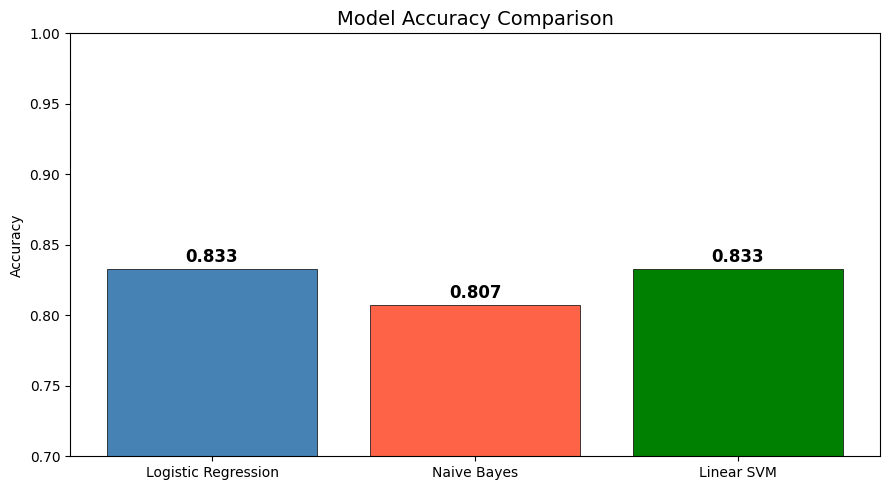

✅ Model comparison chart saved!


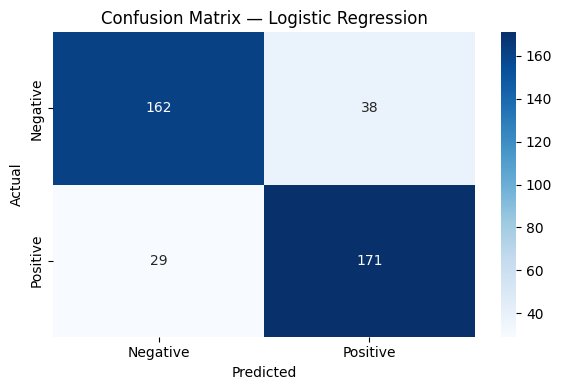

✅ Confusion matrix saved!

🏆 Best Model : Logistic Regression
🏆 Accuracy   : 0.8325
✅ Model saved to     : /Users/pravallikachepuri/sentiment-analysis-nlp/models
✅ Vectorizer saved to: /Users/pravallikachepuri/sentiment-analysis-nlp/models

🎉 Notebook 2 Complete!


In [1]:
# ============================================================
# 🤖 NOTEBOOK 2 — Traditional ML Models
# ============================================================

# ── CELL 1: Imports & Setup ──────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/sentiment-analysis-nlp')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

print("✅ Paths set up!")

# ── CELL 2: Load Cleaned Data ────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_reviews.csv'))
df = df.dropna()

print(f"📌 Loaded dataset : {df.shape}")
print(f"📌 Positive       : {(df['label']==1).sum()}")
print(f"📌 Negative       : {(df['label']==0).sum()}")

# ── CELL 3: TF-IDF Vectorization ────────────────────────────
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X     = tfidf.fit_transform(df['clean_text'])
y     = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📌 Train size     : {X_train.shape}")
print(f"📌 Test size      : {X_test.shape}")
print(f"📌 TF-IDF features: {X.shape[1]}")

# ── CELL 4: Train 3 Models ───────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                               random_state=42),
    'Naive Bayes'        : MultinomialNB(),
    'Linear SVM'         : LinearSVC(max_iter=2000,
                                      random_state=42)
}

results     = {}
predictions = {}

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    model.fit(X_train, y_train)
    y_pred          = model.predict(X_test)
    acc             = accuracy_score(y_test, y_pred)
    results[name]   = acc
    predictions[name] = y_pred

    print(f"{'='*45}")
    print(f"  ✅ {name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
          target_names=['Negative', 'Positive']))

# ── CELL 5: Model Comparison Chart ───────────────────────────
plt.figure(figsize=(9, 5))
colors = ['steelblue', 'tomato', 'green']
bars   = plt.bar(results.keys(), results.values(), color=colors,
                 edgecolor='black', linewidth=0.5)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0.70, 1.0)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=12,
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison.png'))
plt.show()
print("✅ Model comparison chart saved!")

# ── CELL 6: Confusion Matrix for Best Model ──────────────────
best_model_name = max(results, key=results.get)
best_y_pred     = predictions[best_model_name]

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()
print("✅ Confusion matrix saved!")

# ── CELL 7: Save Best Model & Vectorizer ─────────────────────
best_model = models[best_model_name]

with open(os.path.join(MODELS_DIR, 'best_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

print(f"\n🏆 Best Model : {best_model_name}")
print(f"🏆 Accuracy   : {results[best_model_name]:.4f}")
print(f"✅ Model saved to     : {MODELS_DIR}")
print(f"✅ Vectorizer saved to: {MODELS_DIR}")
print("\n🎉 Notebook 2 Complete!")